# Dataset Explorer

This notebook provides tools to explore and analyze the echocardiography dehazing dataset.

**Features:**
- Load and visualize clean, noisy, and ROI images
- Compute image quality metrics (PSNR, SSIM)
- Interactive sample browser
- Save sample visualizations

It auto-detects your dataset under `../Dataset/` (relative to the Notebooks folder).

## Setup

In [11]:
%pip install numpy pandas pillow opencv-python scikit-image ipywidgets matplotlib

  Using cached ipywidgets-8.1.7-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.14-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.7-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl (216 kB)
Using cached widgetsnbextension-4.0.14-py3-none-any.whl (2.2 MB)

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.


In [12]:
import ipywidgets as widgets; widgets.__version__  

'8.1.7'

In [ ]:
import os, re, glob, json, math, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import cv2

DATASET_DIR = Path('../Dataset')
CLEAN_DIR = DATASET_DIR / 'clean'
NOISY_DIR = DATASET_DIR / 'noisy'
ROI_DIR = DATASET_DIR / 'noisy_roi'
OUT_DIR = DATASET_DIR / 'visualizations' / 'notebook'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def parse_filename(fname: str):
    m = re.match(r'patient-(\d+)-4C-frame-(\d+)\.png', fname)
    if not m: return None, None
    return int(m.group(1)), int(m.group(2))

def load_gray(path: Path):
    if not path.exists(): return None
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    return img

def to_rgb(img):
    if img is None: return None
    if len(img.shape) == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img

def side_by_side(images, labels=None, spacing=10):
    imgs = [to_rgb(i) for i in images if i is not None]
    if len(imgs) == 0: return None
    h, w = imgs[0].shape[:2]
    out = np.zeros((h, w*len(imgs)+spacing*(len(imgs)-1), 3), dtype=np.uint8)
    for i, im in enumerate(imgs):
        x = i*(w+spacing)
        out[:, x:x+w] = im
        if i < len(imgs)-1:
            out[:, x+w:x+w+spacing] = 100
    return out

def overlay(noisy, roi, alpha=0.5):
    if noisy is None or roi is None: return None
    n_rgb = to_rgb(noisy)
    r_rgb = to_rgb(roi)
    return cv2.addWeighted(n_rgb, alpha, r_rgb, alpha, 0)

def compute_metrics(clean, noisy):
    if clean is None or noisy is None: return None
    # Ensure same size
    if clean.shape != noisy.shape:
        h = min(clean.shape[0], noisy.shape[0]); w = min(clean.shape[1], noisy.shape[1])
        clean = clean[:h, :w]; noisy = noisy[:h, :w]
    return {
        'psnr': float(psnr(clean, noisy, data_range=255)),
        'ssim': float(ssim(clean, noisy, data_range=255))
    }

def build_mapping_from_fs():
    records = []
    for path in sorted(CLEAN_DIR.glob('*.png')):
        fname = path.name
        p, f = parse_filename(fname)
        if p is None: continue
        rec = {
            'patient_id': p,
            'frame_number': f,
            'clean_image': fname,
            'noisy_image': fname if (NOISY_DIR / fname).exists() else '',
            'noisy_roi_image': fname if (ROI_DIR / fname).exists() else ''
        }
        rec['has_clean'] = rec['clean_image'] != ''
        rec['has_noisy'] = rec['noisy_image'] != ''
        rec['has_roi'] = rec['noisy_roi_image'] != ''
        rec['complete_triplet'] = rec['has_clean'] and rec['has_noisy'] and rec['has_roi']
        rec['clean_noisy_pair'] = rec['has_clean'] and rec['has_noisy']
        records.append(rec)
    return pd.DataFrame(records)

In [ ]:
# Load mapping CSV if present, else scan filesystem
MAPPING_CSV = Path('../Dataset/dataset_mapping.csv')
if MAPPING_CSV.exists():
    df = pd.read_csv(MAPPING_CSV)
else:
    df = build_mapping_from_fs()

In [7]:
print(f'Records: {len(df)} | Triplets: {df.complete_triplet.sum() if "complete_triplet" in df.columns else 0} | Pairs: {df.clean_noisy_pair.sum() if "clean_noisy_pair" in df.columns else 0}')

Records: 4376 | Triplets: 237 | Pairs: 2324


## Dataset summary

In [8]:
# Basic counts
summary = {
    'total_records': len(df),
    'has_clean': int(df.get('has_clean', pd.Series([False]*len(df))).sum()),
    'has_noisy': int(df.get('has_noisy', pd.Series([False]*len(df))).sum()),
    'has_roi': int(df.get('has_roi', pd.Series([False]*len(df))).sum()),
    'complete_triplets': int(df.get('complete_triplet', pd.Series([False]*len(df))).sum()),
    'clean_noisy_pairs': int(df.get('clean_noisy_pair', pd.Series([False]*len(df))).sum())
}
summary

{'total_records': 4376,
 'has_clean': 4376,
 'has_noisy': 2324,
 'has_roi': 237,
 'complete_triplets': 237,
 'clean_noisy_pairs': 2324}

## Random sample previews

<Figure size 640x480 with 0 Axes>

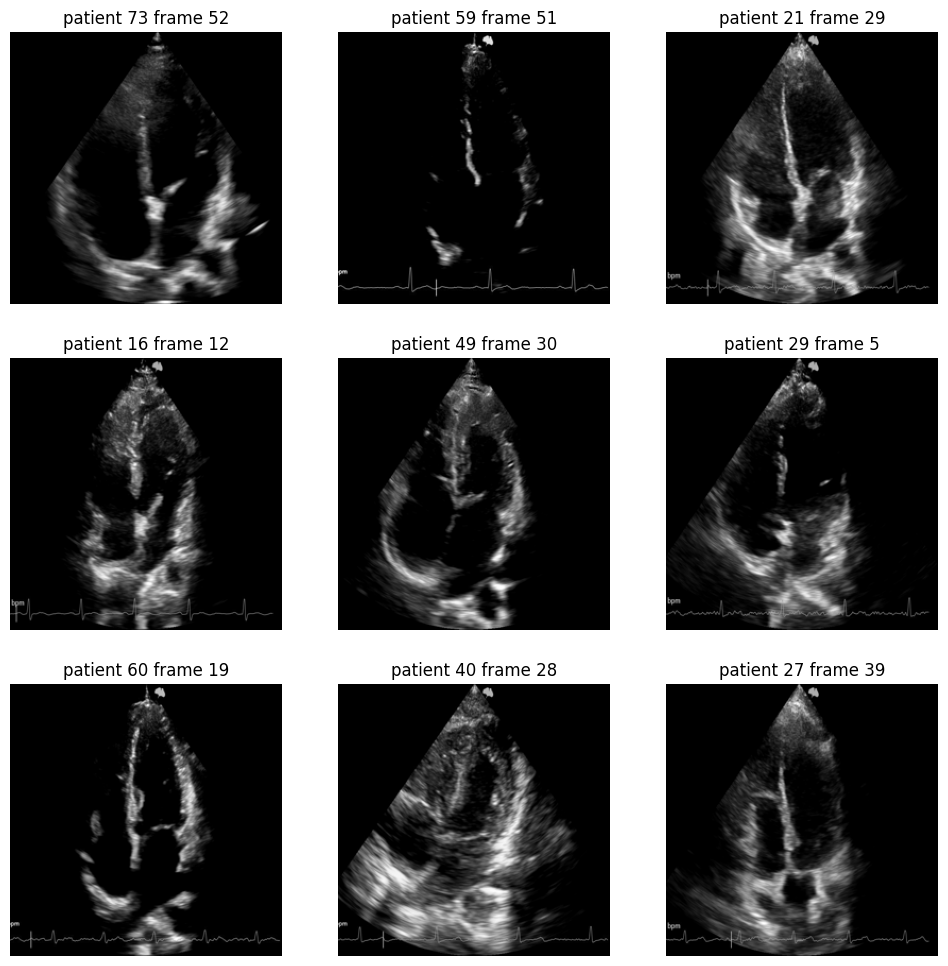

In [13]:
def show_random_grid(df, n=6):
    samples = df.sample(min(n, len(df)), random_state=42)
    cols = 3
    rows = math.ceil(len(samples)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
    axes = np.array(axes).reshape(rows, cols)
    for ax in axes.ravel(): ax.axis('off')
    for (idx, row), ax in zip(samples.iterrows(), axes.ravel()):
        fname = row['clean_image'] if 'clean_image' in row and isinstance(row['clean_image'], str) and row['clean_image'] else row.get('noisy_image', '')
        img = load_gray((CLEAN_DIR if (CLEAN_DIR / str(fname)).exists() else NOISY_DIR) / str(fname)) if fname else None
        if img is not None:
            ax.imshow(img, cmap='gray')
            pid = row.get('patient_id', '?')
            frm = row.get('frame_number', '?')
            ax.set_title(f"patient {pid} frame {frm}")
plt.tight_layout(); plt.show()

show_random_grid(df, n=9)

## Side-by-side comparisons

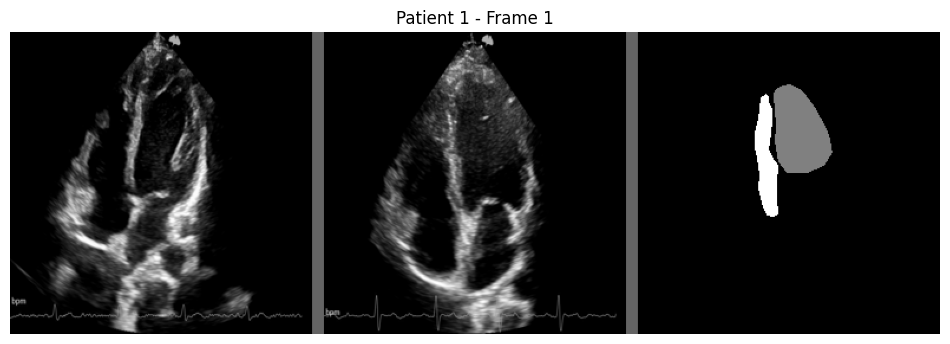

In [14]:
def show_comparison(row):
    fname = row.get('clean_image','') or row.get('noisy_image','')
    clean = load_gray(CLEAN_DIR / fname) if fname else None
    noisy = load_gray(NOISY_DIR / fname) if fname else None
    roi = load_gray(ROI_DIR / fname) if fname else None
    sbs = side_by_side([clean, noisy, roi], labels=['CLEAN','NOISY','ROI'])
    if sbs is None:
        print('Images missing for this row'); return
    plt.figure(figsize=(12,4))
    plt.imshow(sbs)
    plt.axis('off')
    pid = row.get('patient_id','?')
    frm = row.get('frame_number','?')
    plt.title(f"Patient {pid} - Frame {frm}")
    plt.show()

# Show first available triplet or pair
row = df[df.get('complete_triplet', False) == True].head(1)
if len(row) == 0: row = df[df.get('clean_noisy_pair', False) == True].head(1)
if len(row) > 0:
    show_comparison(row.iloc[0])
else:
    print('No comparable pairs/triplets found')

## ROI overlay on noisy

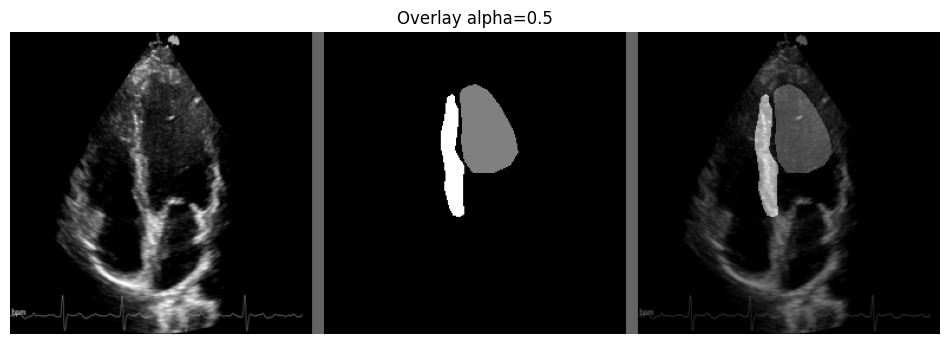

In [15]:
def show_overlay(row, alpha=0.5):
    fname = row.get('noisy_image','') or row.get('clean_image','')
    noisy = load_gray(NOISY_DIR / fname) if fname else None
    roi = load_gray(ROI_DIR / fname) if fname else None
    ov = overlay(noisy, roi, alpha=alpha)
    if ov is None:
        print('Overlay not possible for this row'); return
    comp = side_by_side([noisy, roi, ov])
    plt.figure(figsize=(12,4))
    plt.imshow(comp)
    plt.axis('off')
    plt.title(f"Overlay alpha={alpha}")
    plt.show()

row = df[df.get('has_roi', False) == True].head(1)
if len(row) > 0:
    show_overlay(row.iloc[0], alpha=0.5)
else:
    print('No ROI samples found')

## Metrics (PSNR, SSIM)

In [16]:
def compute_metrics_for_row(row):
    fname = row.get('clean_image','') if isinstance(row.get('clean_image',''), str) else ''
    if not fname: return None
    clean = load_gray(CLEAN_DIR / fname)
    noisy = load_gray(NOISY_DIR / fname)
    if clean is None or noisy is None: return None
    return compute_metrics(clean, noisy)

pairs = df[df.get('clean_noisy_pair', False) == True].head(20)
metrics_list = []
for _, r in pairs.iterrows():
    m = compute_metrics_for_row(r)
    if m: metrics_list.append(m)
metrics_df = pd.DataFrame(metrics_list)
metrics_df.describe()

,psnr,ssim
count,20.000000,20.000000
mean,14.218820,0.548516
std,0.256585,0.012284
min,13.631629,0.523665
25%,14.082051,0.540187
50%,14.233440,0.549081
75%,14.453177,0.556398
max,14.541757,0.567719


## Interactive browser (optional)

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    has_widgets = True
except Exception as e:
    print('ipywidgets not available; skip interactive view')
    has_widgets = False

if has_widgets:
    # Build index of available filenames and filter before sorting to avoid TypeError
    raw_vals = []
    for col in ['clean_image', 'noisy_image', 'noisy_roi_image']:
        if col in df.columns:
            raw_vals.extend(list(df[col]))
    # Keep only strings that look like PNG filenames, then sort
    fnames = sorted({v for v in raw_vals if isinstance(v, str) and v.lower().endswith('.png')})

    dropdown = widgets.Dropdown(options=fnames[:200], description='File:')
    alpha_slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05, description='Overlay α')
    out = widgets.Output()

    def render(fname):
        with out:
            clear_output(wait=True)
            clean = load_gray(CLEAN_DIR / fname)
            noisy = load_gray(NOISY_DIR / fname)
            roi = load_gray(ROI_DIR / fname)
            sbs = side_by_side([clean, noisy, roi])
            ov = overlay(noisy, roi, alpha=alpha_slider.value) if noisy is not None and roi is not None else None
            grid = side_by_side([sbs, ov] if ov is not None else [sbs]) if sbs is not None else None
            if grid is None:
                print('No images available for', fname)
                return
            plt.figure(figsize=(14,5))
            plt.imshow(grid)
            plt.axis('off')
            plt.title(fname)
            plt.show()
            # Metrics
            if clean is not None and noisy is not None:
                m = compute_metrics(clean, noisy)
                print('PSNR: %.2f  SSIM: %.3f' % (m['psnr'], m['ssim']))

    def on_change(change):
        if change['name'] == 'value':
            render(change['new'])
    dropdown.observe(on_change)
    alpha_slider.observe(lambda ch: render(dropdown.value) if ch['name']=='value' else None)
    display(widgets.VBox([widgets.HBox([dropdown, alpha_slider]), out]))
    if dropdown.options:
        render(dropdown.options[0])

## Save a few sample outputs

In [ ]:
def save_sample_outputs(k=10):
    rows = df.head(k)
    for _, row in rows.iterrows():
        fname = row.get('clean_image','') or row.get('noisy_image','')
        if not fname: continue
        clean = load_gray(CLEAN_DIR / fname)
        noisy = load_gray(NOISY_DIR / fname)
        roi = load_gray(ROI_DIR / fname)
        comp = side_by_side([clean, noisy, roi])
        if comp is not None:
            cv2.imwrite(str(OUT_DIR / f'comp_{fname}'), cv2.cvtColor(comp, cv2.COLOR_RGB2BGR))
        ov = overlay(noisy, roi, 0.5)
        if ov is not None:
            cv2.imwrite(str(OUT_DIR / f'overlay_{fname}'), cv2.cvtColor(ov, cv2.COLOR_RGB2BGR))
    return str(OUT_DIR)

save_sample_outputs(10)